# Energy landscapes of the `align_angle` forces

Analytic energy (and, for the bond, force) of each of the six plugin forces vs its
natural variable — numpy only, **no HOOMD run required**. The expressions mirror the
shipped C++/CUDA evaluators (`src/SoftHarmonicTail.h`, the per-class docstrings in
`src/__init__.py`, and README "Mathematical and Physical Details").

Running this notebook displays every curve inline **and** rewrites the PNGs in
`docs/figures/` that the README embeds.

In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt

FIGDIR = "figures"
os.makedirs(FIGDIR, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.3, "axes.axisbelow": True,
    "legend.framealpha": 0.9, "lines.linewidth": 2.0,
})
C = plt.rcParams["axes.prop_cycle"].by_key()["color"]


def save(fig, name):
    """Save a figure into docs/figures/ (leaves it open for inline display)."""
    fig.tight_layout()
    fig.savefig(os.path.join(FIGDIR, name), bbox_inches="tight")
    print("wrote", os.path.join(FIGDIR, name))


# --- Shared soft/capped-harmonic core (mirrors src/SoftHarmonicTail.h) -----
def soft_U(x, k, xc, tail):
    s2 = (x / xc) ** 2
    if tail == "flat":
        return np.where(np.abs(x) < xc, 0.5 * k * x**2 * (1 - s2 + s2**2 / 3), k * xc**2 / 6)
    return np.where(np.abs(x) < xc, 0.5 * k * x**2, k * xc * np.abs(x) - 0.5 * k * xc**2)


def soft_F(x, k, xc, tail):  # restoring force = -dU/dx
    if tail == "flat":
        return np.where(np.abs(x) < xc, -k * x * (1 - (x / xc) ** 2) ** 2, 0.0)
    return np.where(np.abs(x) < xc, -k * x, -k * xc * np.sign(x))


def smoothstep(u, w):  # cubic Hermite envelope
    t = np.clip((u - (1 - w)) / w, 0.0, 1.0)
    return 3 * t**2 - 2 * t**3

## 1. DirectorAlign

wrote figures/directoralign.png


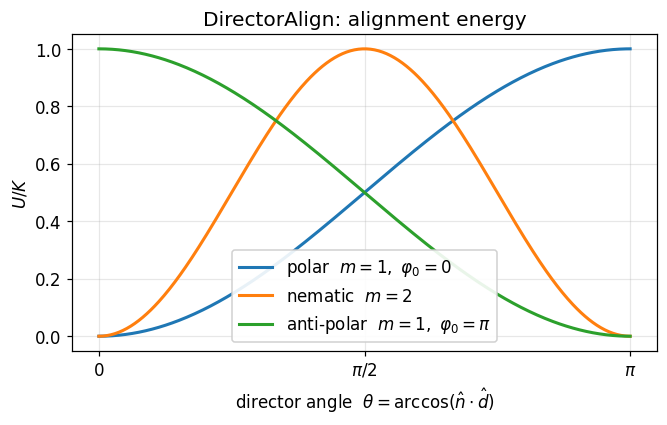

In [2]:
# U(theta) = (K/2) (1 - cos(m*theta + phi0))
th = np.linspace(0, np.pi, 400)
fig, ax = plt.subplots(figsize=(6.2, 4.0))
for (m, phi0, label), c in zip(
    [(1, 0.0, r"polar  $m{=}1,\ \varphi_0{=}0$"),
     (2, 0.0, r"nematic  $m{=}2$"),
     (1, np.pi, r"anti-polar  $m{=}1,\ \varphi_0{=}\pi$")], C):
    ax.plot(th, 0.5 * (1 - np.cos(m * th + phi0)), color=c, label=label)
ax.set_xticks([0, np.pi / 2, np.pi]); ax.set_xticklabels(["0", r"$\pi/2$", r"$\pi$"])
ax.set_title("DirectorAlign: alignment energy")
ax.set_xlabel(r"director angle  $\theta = \arccos(\hat n \cdot \hat d)$")
ax.set_ylabel(r"$U / K$"); ax.legend()
save(fig, "directoralign.png")
plt.show()

## 2. DirectorPair

wrote figures/directorpair.png


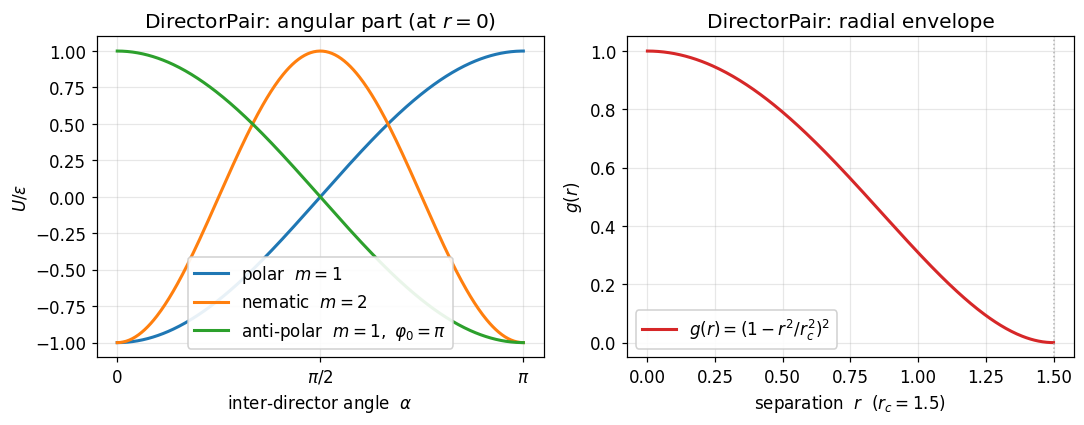

In [3]:
# U = -eps cos(m*alpha + phi0) g(r) ; g(r) = (1 - r^2/rc^2)^2
al = np.linspace(0, np.pi, 400)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.0, 4.0))
for (m, phi0, label), c in zip(
    [(1, 0.0, r"polar  $m{=}1$"),
     (2, 0.0, r"nematic  $m{=}2$"),
     (1, np.pi, r"anti-polar  $m{=}1,\ \varphi_0{=}\pi$")], C):
    a1.plot(al, -np.cos(m * al + phi0), color=c, label=label)  # g = 1 (r = 0)
a1.set_xticks([0, np.pi / 2, np.pi]); a1.set_xticklabels(["0", r"$\pi/2$", r"$\pi$"])
a1.set_title("DirectorPair: angular part (at $r=0$)")
a1.set_xlabel(r"inter-director angle  $\alpha$"); a1.set_ylabel(r"$U / \varepsilon$"); a1.legend()

rc = 1.5
r = np.linspace(0, rc, 300)
a2.plot(r, (1 - r**2 / rc**2) ** 2, color=C[3], label=r"$g(r)=(1-r^2/r_c^2)^2$")
a2.axvline(rc, color="0.7", lw=1, ls=":")
a2.set_title("DirectorPair: radial envelope")
a2.set_xlabel(r"separation  $r$  ($r_c=1.5$)"); a2.set_ylabel(r"$g(r)$"); a2.legend()
save(fig, "directorpair.png")
plt.show()

## 3. SinSqDihedral

wrote figures/sinsqdihedral.png


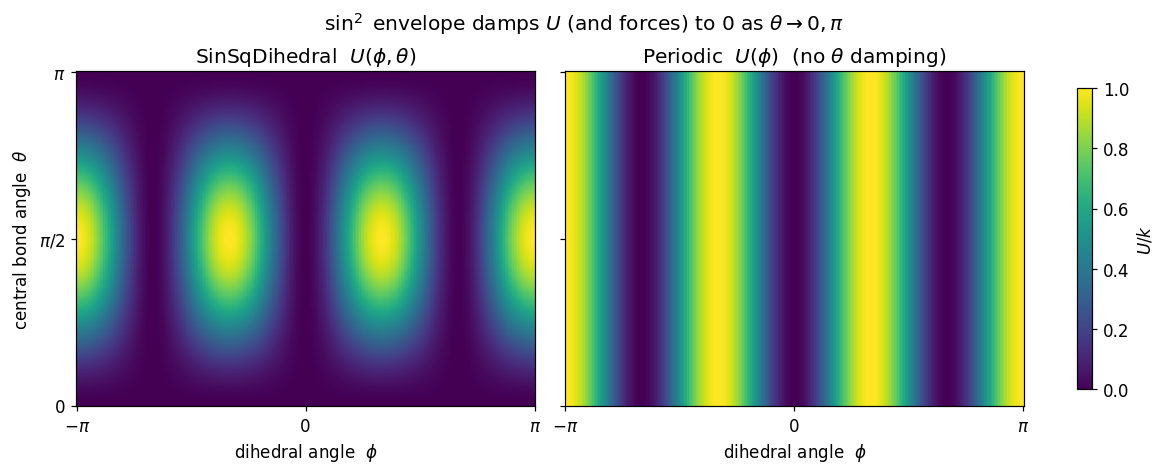

In [4]:
# SinSqDihedral is singularity-free: the periodic torsion is multiplied by
# sin^2(theta_abc) * sin^2(theta_bcd). A 2D map over (dihedral phi, central bond
# angle theta) shows the sin^2 envelope damping the energy -- and, crucially, the
# forces -- to zero at collinear geometries (theta -> 0, pi). The standard Periodic
# dihedral has no such damping and its forces diverge there.
n, d, phi0, k = 3, -1, 0.0, 1.0
phi = np.linspace(-np.pi, np.pi, 300)
th = np.linspace(0, np.pi, 300)
PHI, TH = np.meshgrid(phi, th)
torsion = 0.5 * k * (1 + d * np.cos(n * PHI - phi0))
U_sinsq = torsion * np.sin(TH) ** 2   # theta_bcd fixed at 90 deg (sin^2 = 1)
U_periodic = torsion                  # standard Periodic dihedral: no theta damping

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.5, 4.2), sharey=True, constrained_layout=True)
vmax = float(U_periodic.max())
for ax, Z, title in [(a1, U_sinsq, r"SinSqDihedral  $U(\phi,\theta)$"),
                     (a2, U_periodic, r"Periodic  $U(\phi)$  (no $\theta$ damping)")]:
    pc = ax.pcolormesh(phi, th, Z, cmap="viridis", vmin=0, vmax=vmax, shading="auto")
    ax.grid(False)
    ax.set_xlabel(r"dihedral angle  $\phi$")
    ax.set_xticks([-np.pi, 0, np.pi]); ax.set_xticklabels([r"$-\pi$", "0", r"$\pi$"])
    ax.set_title(title)
a1.set_ylabel(r"central bond angle  $\theta$")
a1.set_yticks([0, np.pi / 2, np.pi]); a1.set_yticklabels(["0", r"$\pi/2$", r"$\pi$"])
fig.colorbar(pc, ax=[a1, a2], label=r"$U / k$", shrink=0.9)
fig.suptitle(r"$\sin^2$ envelope damps $U$ (and forces) to 0 as $\theta \to 0,\pi$")
fig.savefig(os.path.join(FIGDIR, "sinsqdihedral.png"), bbox_inches="tight")
print("wrote", os.path.join(FIGDIR, "sinsqdihedral.png"))
plt.show()

## 4. SoftHarmonic (bond)

wrote figures/softharmonic_bond.png


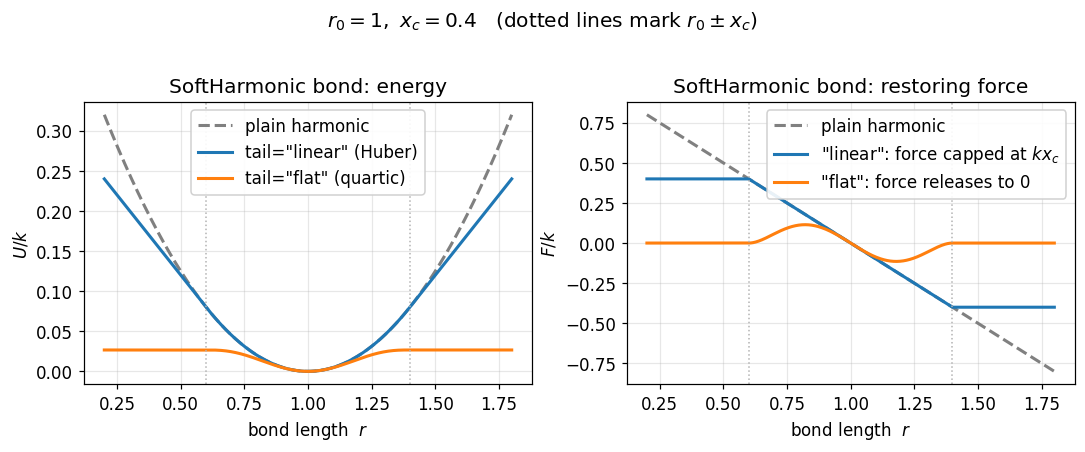

In [5]:
# SoftHarmonic bond: U(r) and F(r) for both tails vs plain harmonic
r0, xc, k = 1.0, 0.4, 1.0
r = np.linspace(r0 - 2.0 * xc, r0 + 2.0 * xc, 500)
x = r - r0
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.0, 4.0))
a1.plot(r, 0.5 * k * x**2, "--", color="0.5", label="plain harmonic")
a1.plot(r, soft_U(x, k, xc, "linear"), color=C[0], label='tail="linear" (Huber)')
a1.plot(r, soft_U(x, k, xc, "flat"), color=C[1], label='tail="flat" (quartic)')
for xv in (r0 - xc, r0 + xc):
    a1.axvline(xv, color="0.7", lw=1, ls=":")
a1.set_title("SoftHarmonic bond: energy")
a1.set_xlabel(r"bond length  $r$"); a1.set_ylabel(r"$U / k$"); a1.legend()

a2.plot(r, -k * x, "--", color="0.5", label="plain harmonic")
a2.plot(r, soft_F(x, k, xc, "linear"), color=C[0], label='"linear": force capped at $k x_c$')
a2.plot(r, soft_F(x, k, xc, "flat"), color=C[1], label='"flat": force releases to 0')
for xv in (r0 - xc, r0 + xc):
    a2.axvline(xv, color="0.7", lw=1, ls=":")
a2.set_title("SoftHarmonic bond: restoring force")
a2.set_xlabel(r"bond length  $r$"); a2.set_ylabel(r"$F / k$"); a2.legend()
fig.suptitle(r"$r_0=1,\ x_c=0.4$   (dotted lines mark $r_0 \pm x_c$)", y=1.02)
save(fig, "softharmonic_bond.png")
plt.show()

## 5. SoftHarmonicAngle (angle)

wrote figures/softharmonic_angle.png


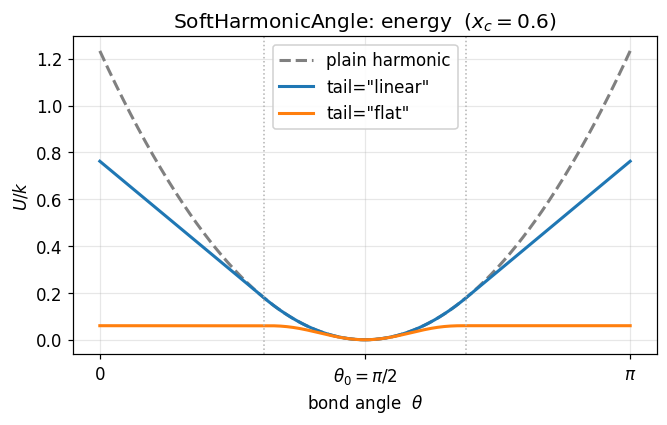

In [6]:
# SoftHarmonicAngle: U(theta) for both tails
t0, xc, k = np.pi / 2, 0.6, 1.0
th = np.linspace(0, np.pi, 500)
x = th - t0
fig, ax = plt.subplots(figsize=(6.2, 4.0))
ax.plot(th, 0.5 * k * x**2, "--", color="0.5", label="plain harmonic")
ax.plot(th, soft_U(x, k, xc, "linear"), color=C[0], label='tail="linear"')
ax.plot(th, soft_U(x, k, xc, "flat"), color=C[1], label='tail="flat"')
for xv in (t0 - xc, t0 + xc):
    ax.axvline(xv, color="0.7", lw=1, ls=":")
ax.set_xticks([0, np.pi / 2, np.pi]); ax.set_xticklabels(["0", r"$\theta_0=\pi/2$", r"$\pi$"])
ax.set_title(r"SoftHarmonicAngle: energy  ($x_c=0.6$)")
ax.set_xlabel(r"bond angle  $\theta$"); ax.set_ylabel(r"$U / k$"); ax.legend()
save(fig, "softharmonic_angle.png")
plt.show()

## 6. ExternalPatch

wrote figures/externalpatch.png


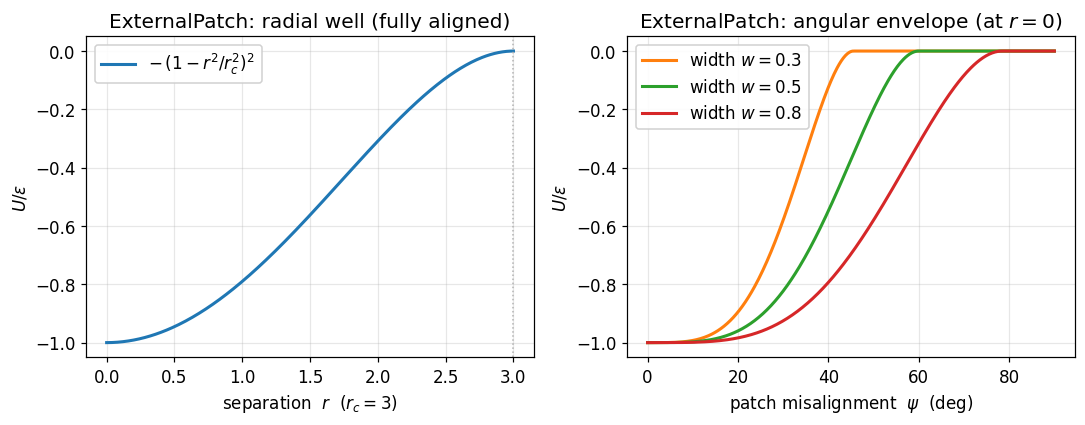

In [7]:
# ExternalPatch: U = -eps (1 - r^2/rc^2)^2 * f_i * f_k, Hermite envelope
rc = 3.0
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.0, 4.0))
r = np.linspace(0, rc, 300)
a1.plot(r, -(1 - r**2 / rc**2) ** 2, color=C[0], label=r"$-\,(1-r^2/r_c^2)^2$")
a1.axvline(rc, color="0.7", lw=1, ls=":")
a1.set_title("ExternalPatch: radial well (fully aligned)")
a1.set_xlabel(r"separation  $r$  ($r_c=3$)"); a1.set_ylabel(r"$U / \varepsilon$"); a1.legend()

psi = np.linspace(0, np.pi / 2, 400)
u = np.cos(psi)
for w, c in zip([0.3, 0.5, 0.8], [C[1], C[2], C[3]]):
    a2.plot(np.degrees(psi), -smoothstep(u, w), color=c, label=f"width $w={w}$")
a2.set_title("ExternalPatch: angular envelope (at $r=0$)")
a2.set_xlabel(r"patch misalignment  $\psi$  (deg)"); a2.set_ylabel(r"$U / \varepsilon$"); a2.legend()
save(fig, "externalpatch.png")
plt.show()